---
title: "Lab 2 · Auditoría rápida de un pipeline de datos"
subtitle: "Encuentro 2 · Unidad 1"
---

::: {.rds-meta}
[Laboratorio 2]{} [Encuentro 2]{} [≈ 40 minutos]{} [Python · pandas · scikit-learn]{}
:::

Dos partes:

**A · La auditoría.** Construimos, en código, la matriz
`etapa · dato · riesgo · pregunta · control · decisión` para el proyecto
DataMarket.

**B · Los dos modelos.** Entrenamos una regresión logística de *churn* en dos
versiones y las comparamos. **No** es un ejercicio de rendimiento predictivo:
las métricas están para sostener una discusión.

::: {.rds-sintetico}
Base sintética generada por `scripts/generar_datos.py`. Ninguna persona real
está representada.
:::

## 0 · Preparación

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

RUTA = Path("../data/clientes_sinteticos.csv")
if not RUTA.exists():
    RUTA = Path("data/clientes_sinteticos.csv")

df = pd.read_csv(RUTA, parse_dates=["fecha_ultima_compra", "fecha_autorizacion"])
print(f"{df.shape[0]} registros · {df.shape[1]} variables")

1512 registros · 35 variables


# Parte A · La auditoría del pipeline

## 1 · Origen

Primera etapa: ¿de dónde vienen estos datos? La respuesta no es «de la base
de datos». La base de datos es dónde están, no de dónde vienen.

In [2]:
origen = (
    df["origen_dato"].value_counts()
    .to_frame("registros")
    .assign(**{"%": lambda d: (d["registros"] / len(df) * 100).round(1)})
)
origen["con_autorizacion_fechada"] = (
    df.groupby("origen_dato")["fecha_autorizacion"].apply(lambda s: s.notna().sum())
)
origen["consent_marketing"] = df.groupby("origen_dato")["consentimiento_marketing"].sum()
origen

,registros,%,con_autorizacion_fechada,consent_marketing
origen_dato,,,,
facturacion,464,30.7,464,72
entrega_domicilio,348,23.0,348,45
registro_cuenta,289,19.1,289,140
programa_fidelizacion,175,11.6,175,159
lista_comprada_tercero,144,9.5,0,2
enriquecimiento_web,92,6.1,0,5


::: {.rds-card .riesgo}
**Pregunta 1.** Dos orígenes no tienen ni una sola autorización fechada.
¿Cuáles son, cuántos registros suman y qué significa eso para el proyecto?

Fíjese también en `consent_marketing`: la autorización de marketing no se
distribuye de forma pareja. ¿Qué implicación tiene para la petición de
«publicidad personalizada» que llegó esta semana?
:::

## 2 · Finalidad

El encargo original fue: facturación, entregas y administración de clientes.
La petición nueva es: segmentación, predicción, publicidad y recomendación.

Marcamos qué registros podemos usar para una finalidad de **analítica
interna** y cuáles no.

In [3]:
ORIGENES_SIN_EVIDENCIA = ["lista_comprada_tercero", "enriquecimiento_web"]

df["evidencia_origen"] = np.where(
    df["origen_dato"].isin(ORIGENES_SIN_EVIDENCIA), "sin evidencia", "con evidencia"
)

resumen_finalidad = (
    df.groupby("evidencia_origen")
      .agg(registros=("cliente_id", "size"),
           tasa_churn=("churn", "mean"))
      .round(3)
)
resumen_finalidad

,registros,tasa_churn
evidencia_origen,,
con evidencia,1276,0.276
sin evidencia,236,0.275


In [4]:
# Decisión: los registros sin evidencia se AÍSLAN, no se borran.
# Borrarlos destruiría la prueba de que existieron.
df_apto = df[df["evidencia_origen"] == "con evidencia"].copy()
df_aislado = df[df["evidencia_origen"] == "sin evidencia"].copy()

print(f"Base original            : {len(df):>5} registros")
print(f"Aptos para entrenamiento : {len(df_apto):>5} registros")
print(f"Aislados (sin evidencia) : {len(df_aislado):>5} registros"
      f"  ({len(df_aislado) / len(df) * 100:.1f} %)")

Base original            :  1512 registros
Aptos para entrenamiento :  1276 registros
Aislados (sin evidencia) :   236 registros  (15.6 %)


::: {.rds-card .decide}
**Pregunta 2.** Perdimos un 15 % de los registros. La Dirección Comercial va
a preguntar por qué el modelo se entrenó con menos datos.

Escriba la respuesta en **dos frases**, sin usar la palabra «ley».
:::

## 3 · Alcance territorial

Antes de seguir: ¿dónde están las personas de esta base?

In [5]:
UE = {"Espana", "Alemania", "Francia", "Italia"}

territorio = df["pais_residencia"].value_counts().to_frame("registros")
territorio["régimen probable"] = np.where(
    territorio.index.isin(UE), "GDPR (UE)",
    np.where(territorio.index == "Colombia", "Ley 1581 de 2012", "otro / verificar"),
)
territorio

,registros,régimen probable
pais_residencia,,
Colombia,1363,Ley 1581 de 2012
Espana,38,GDPR (UE)
Mexico,34,otro / verificar
Estados Unidos,28,otro / verificar
Alemania,16,GDPR (UE)
Ecuador,13,otro / verificar
Italia,11,GDPR (UE)
Francia,9,GDPR (UE)


::: {.rds-card .riesgo}
**Pregunta 3.** ¿Cuántos residentes en la UE hay? Es un número pequeño frente
al total.

¿Cambia algo que sean pocos? ¿Por qué sí o por qué no? Esta pregunta es el
punto de partida de la [Actividad 2](../actividades/actividad-02.qmd).
:::

## 4 · Feature engineering: las inferencias que creamos nosotros

Esta es la etapa donde el analista **fabrica** datos nuevos sobre personas.
Construimos tres variables derivadas. Ninguna estaba en la base original.

In [6]:
CORTE = pd.Timestamp("2026-08-31")   # fecha de corte del análisis

df_apto["dias_desde_ultima_compra"] = (CORTE - df_apto["fecha_ultima_compra"]).dt.days
df_apto["ticket_promedio"] = np.where(
    df_apto["compras_6m"] > 0, df_apto["monto_compras"] / df_apto["compras_6m"], 0
)
df_apto["intensidad_navegacion"] = (
    df_apto["productos_vistos"] / df_apto["visitas_web"].clip(lower=1)
)

df_apto[["dias_desde_ultima_compra", "ticket_promedio", "intensidad_navegacion"]].describe().round(2)

,dias_desde_ultima_compra,ticket_promedio,intensidad_navegacion
count,1276.00,1276.00,1276.00
mean,112.46,123703.89,2.10
std,78.01,84791.78,0.76
min,1.00,0.00,0.78
25%,53.00,70000.00,1.44
50%,107.50,108500.00,2.12
75%,158.00,165625.00,2.78
max,418.00,587714.29,3.41


::: {.rds-card .decide}
**Pregunta 4.** Las tres variables anteriores son inofensivas.

Ahora piense en tres más que el equipo de marketing *podría* pedir y que no
lo serían. Escríbalas con el nombre que tendrían en el código.

Pista: con `compras_farmacia_6m`, `busquedas_maternidad` y `edad` se pueden
construir varias.
:::

## 5 · La matriz de auditoría

Ahora la construimos completa, en código, para que quede como artefacto
reproducible del proyecto y no como un documento de Word que nadie actualiza.

In [7]:
auditoria = pd.DataFrame([
    dict(etapa="Origen",
         dato="origen_dato, fecha_autorizacion",
         riesgo="236 registros sin evidencia de autorización",
         pregunta="¿De dónde vienen y para qué se recogieron?",
         control="Aislar los registros sin evidencia",
         decision="Excluidos del entrenamiento; conservados aparte"),

    dict(etapa="Datos",
         dato="nombre, email, telefono, documento, direccion",
         riesgo="Identificadores directos en el archivo de trabajo",
         pregunta="¿Los necesito para esta finalidad?",
         control="Minimizar: no cargarlos en el dataset de modelado",
         decision="Excluidos; se conserva solo cliente_id"),

    dict(etapa="Finalidad",
         dato="toda la base",
         riesgo="Uso secundario: publicidad con datos de facturación",
         pregunta="¿Es la misma finalidad de recolección?",
         control="Separar analítica interna de comunicación a terceros",
         decision="Publicidad personalizada: requiere autorización específica"),

    dict(etapa="Procesamiento",
         dato="variables derivadas",
         riesgo="Crear inferencias sobre condiciones sensibles",
         pregunta="¿Qué estoy deduciendo que la persona no declaró?",
         control="Lista blanca de variables derivadas permitidas",
         decision="Solo recencia, ticket e intensidad de navegación"),

    dict(etapa="Modelo",
         dato="estrato, ingresos, edad, proxies de salud",
         riesgo="Perfilamiento con proxies de datos sensibles",
         pregunta="¿El modelo distingue por condición socioeconómica o de salud?",
         control="Comparar modelo A y modelo B; medir error por grupo",
         decision="Ver Parte B de este laboratorio"),

    dict(etapa="Resultado",
         dato="probabilidad de churn",
         riesgo="Score tratado como verdad sobre la persona",
         pregunta="¿Qué error es aceptable y para quién?",
         control="Documentar umbral y matriz de confusión por grupo",
         decision="Umbral fijado con la Dirección, no por el analista"),

    dict(etapa="Decisión",
         dato="acción comercial asociada al score",
         riesgo="Decisión totalmente automatizada con efecto sobre la persona",
         pregunta="¿Hay intervención humana significativa?",
         control="Revisión humana antes de aplicar la acción",
         decision="La campaña se aprueba por lote, no cliente por cliente"),

    dict(etapa="Publicación",
         dato="tablero y archivo entregado a terceros",
         riesgo="Reidentificación por cruce de cuasi-identificadores",
         pregunta="¿Alguien puede ser identificado en lo que publico?",
         control="Agregación y supresión de celdas pequeñas",
         decision="Umbral mínimo de celda a definir; ver Actividad 4"),
])

auditoria

,etapa,dato,riesgo,pregunta,control,decision
0,Origen,"origen_dato, fecha_autorizacion",236 registros sin evidencia de autorización,¿De dónde vienen y para qué se recogieron?,Aislar los registros sin evidencia,Excluidos del entrenamiento; conservados aparte
1,Datos,"nombre, email, telefono, documento, direccion",Identificadores directos en el archivo de trabajo,¿Los necesito para esta finalidad?,Minimizar: no cargarlos en el dataset de modelado,Excluidos; se conserva solo cliente_id
2,Finalidad,toda la base,Uso secundario: publicidad con datos de factur...,¿Es la misma finalidad de recolección?,Separar analítica interna de comunicación a te...,Publicidad personalizada: requiere autorizació...
3,Procesamiento,variables derivadas,Crear inferencias sobre condiciones sensibles,¿Qué estoy deduciendo que la persona no declaró?,Lista blanca de variables derivadas permitidas,"Solo recencia, ticket e intensidad de navegación"
4,Modelo,"estrato, ingresos, edad, proxies de salud",Perfilamiento con proxies de datos sensibles,¿El modelo distingue por condición socioeconóm...,Comparar modelo A y modelo B; medir error por ...,Ver Parte B de este laboratorio
5,Resultado,probabilidad de churn,Score tratado como verdad sobre la persona,¿Qué error es aceptable y para quién?,Documentar umbral y matriz de confusión por grupo,"Umbral fijado con la Dirección, no por el anal..."
6,Decisión,acción comercial asociada al score,Decisión totalmente automatizada con efecto so...,¿Hay intervención humana significativa?,Revisión humana antes de aplicar la acción,"La campaña se aprueba por lote, no cliente por..."
7,Publicación,tablero y archivo entregado a terceros,Reidentificación por cruce de cuasi-identifica...,¿Alguien puede ser identificado en lo que publ...,Agregación y supresión de celdas pequeñas,Umbral mínimo de celda a definir; ver Actividad 4


In [8]:
# La auditoría se guarda como evidencia del proyecto.
destino = Path("auditoria_pipeline_datamarket.csv")
auditoria.to_csv(destino, index=False, encoding="utf-8")
print("Evidencia escrita en:", destino.name)

Evidencia escrita en: auditoria_pipeline_datamarket.csv


::: {.rds-card .decision}
**Pregunta 5.** La fila «Publicación» dice «umbral mínimo de celda a definir».
Es la única de las ocho que queda abierta.

Proponga un umbral y justifíquelo en una frase. No hay respuesta correcta;
hay respuestas documentadas y respuestas no documentadas.
:::

# Parte B · Los dos modelos

## 6 · Definir los dos conjuntos de variables

La diferencia entre A y B no es técnica: es una decisión sobre qué estamos
dispuestos a usar.

In [9]:
VARIABLES_A = [
    "visitas_web",
    "productos_vistos",
    "compras_6m",
    "monto_compras",
    "dias_desde_ultima_compra",
    "ticket_promedio",
    "intensidad_navegacion",
]

VARIABLES_EXTRA_B = [
    "edad",                   # cuasi-identificador
    "estrato",                # proxy socioeconómico
    "ingresos_mensuales",     # proxy socioeconómico
    "compras_farmacia_6m",    # proxy de salud
    "entrega_asistida",       # proxy de discapacidad / edad avanzada
    "busquedas_maternidad",   # proxy de embarazo
]

VARIABLES_B = VARIABLES_A + VARIABLES_EXTRA_B

print(f"Modelo A: {len(VARIABLES_A)} variables (solo comportamiento)")
print(f"Modelo B: {len(VARIABLES_B)} variables (comportamiento + demografía + proxies)")

Modelo A: 7 variables (solo comportamiento)
Modelo B: 13 variables (comportamiento + demografía + proxies)


::: {.rds-card .codigo}
`score_riesgo_interno` y `segmento` **no** entran en ninguno de los dos
modelos, aunque estén en la base. Son datos inferidos por un modelo anterior
de la propia empresa: usarlos como predictores mezcla la salida de un sistema
con la entrada de otro y hace imposible auditar de dónde salió una decisión.

Excluirlos es, también, una decisión que hay que documentar.
:::

## 7 · Entrenar y comparar

In [10]:
y = df_apto["churn"]


def entrenar(variables: list, etiqueta: str, semilla: int = 42) -> dict:
    X = df_apto[variables].copy()
    X = X.fillna(X.median(numeric_only=True))

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.30, random_state=semilla, stratify=y
    )
    modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    modelo.fit(X_tr, y_tr)

    p_te = modelo.predict_proba(X_te)[:, 1]
    return {
        "etiqueta": etiqueta,
        "modelo": modelo,
        "variables": variables,
        "auc": roc_auc_score(y_te, p_te),
        "X_te": X_te,
        "y_te": y_te,
        "p_te": p_te,
    }


modelo_a = entrenar(VARIABLES_A, "Modelo A · solo comportamiento")
modelo_b = entrenar(VARIABLES_B, "Modelo B · + demografía y proxies")

print(f"{modelo_a['etiqueta']:<42} AUC = {modelo_a['auc']:.3f}")
print(f"{modelo_b['etiqueta']:<42} AUC = {modelo_b['auc']:.3f}")
print(f"{'Diferencia':<42}     + {modelo_b['auc'] - modelo_a['auc']:.3f}")

Modelo A · solo comportamiento             AUC = 0.833
Modelo B · + demografía y proxies          AUC = 0.875
Diferencia                                     + 0.042


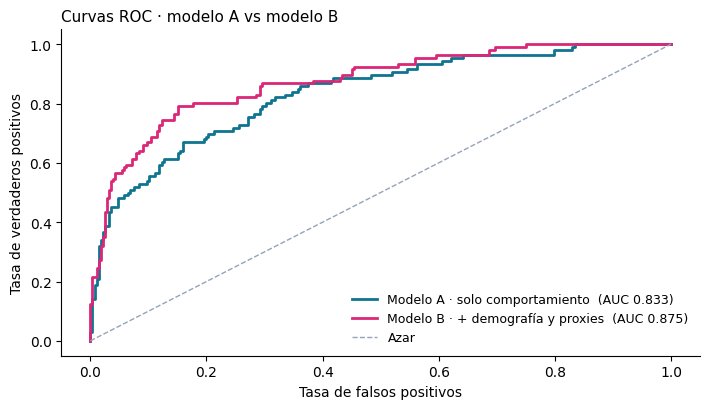

In [11]:
fig, ax = plt.subplots()
for m, color in [(modelo_a, "#0e7490"), (modelo_b, "#db2777")]:
    fpr, tpr, _ = roc_curve(m["y_te"], m["p_te"])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{m['etiqueta']}  (AUC {m['auc']:.3f})")

ax.plot([0, 1], [0, 1], color="#94a3b8", lw=1, ls="--", label="Azar")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curvas ROC · modelo A vs modelo B", loc="left", fontsize=11)
ax.legend(loc="lower right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

::: {.rds-card .dilema}
**Pregunta 6.** Ahí está la diferencia, medida.

::: {.pregunta}
¿Es suficiente que B tenga mayor AUC para preferirlo?
:::

Antes de responder, los bloques 8 y 9 contestan las dos preguntas auxiliares:
*qué* variables aportan la diferencia y *sobre quién* se equivoca cada modelo.
:::

## 8 · ¿Qué variables aportan la diferencia?

Los coeficientes de una regresión logística estandarizada son directamente
comparables entre sí.

In [12]:
coefs = pd.Series(
    modelo_b["modelo"].named_steps["logisticregression"].coef_[0],
    index=VARIABLES_B,
    name="coeficiente",
).sort_values(key=abs, ascending=False)

tabla_coefs = coefs.to_frame().round(3)
tabla_coefs["tipo"] = np.where(
    tabla_coefs.index.isin(VARIABLES_EXTRA_B), "demografía / proxy", "comportamiento"
)
tabla_coefs

,coeficiente,tipo
dias_desde_ultima_compra,0.890,comportamiento
compras_6m,-0.746,comportamiento
edad,0.524,demografía / proxy
compras_farmacia_6m,0.410,demografía / proxy
estrato,-0.405,demografía / proxy
busquedas_maternidad,-0.342,demografía / proxy
entrega_asistida,0.248,demografía / proxy
productos_vistos,-0.213,comportamiento
visitas_web,0.178,comportamiento
ticket_promedio,-0.161,comportamiento


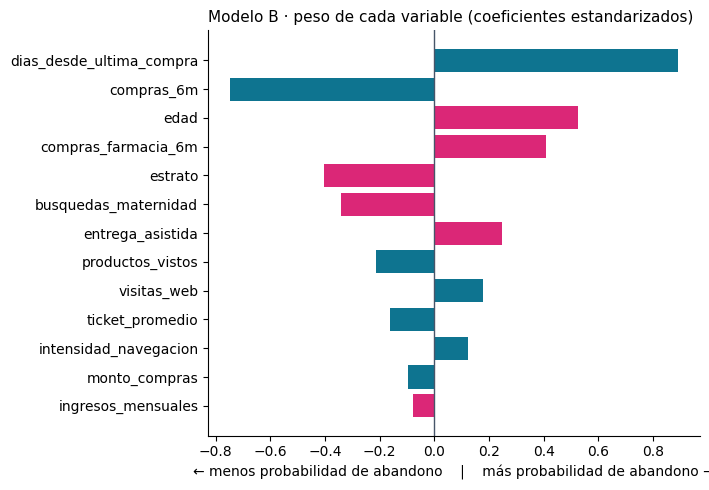

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 5))
colores = ["#db2777" if v in VARIABLES_EXTRA_B else "#0e7490" for v in coefs.index]
ax.barh(coefs.index[::-1], coefs.values[::-1], color=colores[::-1])
ax.axvline(0, color="#475569", lw=1)
ax.set_title("Modelo B · peso de cada variable (coeficientes estandarizados)",
             loc="left", fontsize=11)
ax.set_xlabel("← menos probabilidad de abandono    |    más probabilidad de abandono →")
plt.tight_layout()
plt.show()

::: {.rds-card .riesgo}
**Pregunta 7.** Mire las barras magenta: son las variables que el modelo A no
tiene.

Si alguna de ellas está entre las de mayor peso, el modelo B no está
prediciendo mejor *el comportamiento*: está prediciendo mejor *la condición
social o de salud de la persona*, y usándola para decidir sobre ella.

¿Cuál es la variable de mayor peso del bloque magenta? ¿Se siente cómodo
explicándosela a un cliente?
:::

## 9 · ¿Sobre quién se equivoca cada modelo?

Un AUC global puede ocultar comportamientos muy distintos por grupo. Medimos
la tasa de falsos positivos por estrato socioeconómico.

In [14]:
UMBRAL = 0.50


def error_por_grupo(m: dict, variable_grupo: str) -> pd.DataFrame:
    grupo = df_apto.loc[m["X_te"].index, variable_grupo]
    pred = (m["p_te"] >= UMBRAL).astype(int)
    eval_df = pd.DataFrame({"grupo": grupo, "real": m["y_te"].values, "pred": pred})

    filas = []
    for nombre, sub in eval_df.groupby("grupo", dropna=True):
        if len(sub) < 20:            # grupos muy pequeños: no se reporta
            continue
        tn, fp, fn, tp = confusion_matrix(sub["real"], sub["pred"], labels=[0, 1]).ravel()
        filas.append({
            "grupo": nombre,
            "n": len(sub),
            "tasa_churn_real": round(sub["real"].mean(), 3),
            "marcados_como_riesgo": round(sub["pred"].mean(), 3),
            "falsos_positivos": round(fp / max(tn + fp, 1), 3),
            "falsos_negativos": round(fn / max(tp + fn, 1), 3),
        })
    return pd.DataFrame(filas).set_index("grupo")


print("=== MODELO A · por estrato ===")
print(error_por_grupo(modelo_a, "estrato").to_string())
print()
print("=== MODELO B · por estrato ===")
print(error_por_grupo(modelo_b, "estrato").to_string())

=== MODELO A · por estrato ===
         n  tasa_churn_real  marcados_como_riesgo  falsos_positivos  falsos_negativos
grupo                                                                                
1.0     31            0.419                 0.097             0.000             0.769
2.0     79            0.342                 0.139             0.000             0.593
3.0    108            0.343                 0.139             0.028             0.649
4.0     72            0.167                 0.111             0.050             0.583
5.0     50            0.100                 0.060             0.022             0.600
6.0     23            0.174                 0.174             0.053             0.250

=== MODELO B · por estrato ===
         n  tasa_churn_real  marcados_como_riesgo  falsos_positivos  falsos_negativos
grupo                                                                                
1.0     31            0.419                 0.290             0.000          

::: {.rds-card .riesgo}
**Pregunta 8.** Compare la columna `marcados_como_riesgo` entre estratos, en
cada modelo.

Si el modelo B marca como «en riesgo de abandono» a una proporción mucho mayor
de clientes de estratos bajos, y la acción asociada es *dar menos beneficios a
quien se va a ir de todos modos*, el modelo acaba de convertirse en un
mecanismo de exclusión con apariencia técnica.

¿Ocurre eso aquí? Responda con los números de la tabla, no con la intuición.
:::

## 10 · La decisión no está en el modelo: está en lo que se hace con él

La misma predicción, dos acciones distintas, dos perfiles de daño distintos.

In [15]:
acciones = pd.DataFrame([
    dict(accion="Oferta de retención (descuento)",
         falso_positivo="Se da un descuento a quien no se iba a ir → costo para la empresa",
         falso_negativo="Se pierde un cliente que se podía retener → costo para la empresa",
         quien_asume_el_dano="La empresa"),
    dict(accion="Menor prioridad en atención al cliente",
         falso_positivo="Peor servicio a quien no se iba a ir → daño a la persona",
         falso_negativo="Servicio normal a quien se va → costo menor para la empresa",
         quien_asume_el_dano="La persona"),
    dict(accion="Precio personalizado más alto",
         falso_positivo="Sobreprecio a quien no se iba a ir → daño a la persona",
         falso_negativo="Precio normal → sin daño",
         quien_asume_el_dano="La persona"),
])

for _, fila in acciones.iterrows():
    print(f"\n▸ {fila['accion']}")
    print(f"   FP: {fila['falso_positivo']}")
    print(f"   FN: {fila['falso_negativo']}")
    print(f"   Daño: lo asume {fila['quien_asume_el_dano'].lower()}")


▸ Oferta de retención (descuento)
   FP: Se da un descuento a quien no se iba a ir → costo para la empresa
   FN: Se pierde un cliente que se podía retener → costo para la empresa
   Daño: lo asume la empresa

▸ Menor prioridad en atención al cliente
   FP: Peor servicio a quien no se iba a ir → daño a la persona
   FN: Servicio normal a quien se va → costo menor para la empresa
   Daño: lo asume la persona

▸ Precio personalizado más alto
   FP: Sobreprecio a quien no se iba a ir → daño a la persona
   FN: Precio normal → sin daño
   Daño: lo asume la persona


::: {.rds-card .decision}
**Pregunta 9.** El modelo es exactamente el mismo en las tres filas.

Lo que cambia es quién asume el daño del error. Un equipo de analítica que
solo optimiza AUC no tiene forma de ver esta diferencia, porque la métrica no
la contiene.

Escriba la decisión final del laboratorio:

1. ¿Qué modelo se despliega, A o B?
2. ¿Con qué acción asociada?
3. ¿Qué condición tendría que cumplirse para cambiar de opinión?
:::

## 11 · Registrar la decisión

Una decisión sin evidencia no cuenta como decisión. Cerramos el laboratorio
escribiendo el registro.

In [16]:
registro = pd.DataFrame([
    dict(
        proyecto="DataMarket · modelo de churn",
        fecha=str(pd.Timestamp("today").date()),
        modelo_desplegado="A (solo comportamiento)",
        auc_a=round(modelo_a["auc"], 3),
        auc_b=round(modelo_b["auc"], 3),
        diferencia_auc=round(modelo_b["auc"] - modelo_a["auc"], 3),
        motivo_exclusion_b=("B mejora el AUC usando estrato, ingresos y proxies de "
                            "salud; no hay finalidad documentada que habilite su uso "
                            "ni control sobre el efecto de la decisión."),
        registros_excluidos=len(df_aislado),
        variables_excluidas="; ".join(VARIABLES_EXTRA_B),
        revision_humana="Sí · la campaña se aprueba por lote",
        decidido_por="Equipo de analítica + Dirección Comercial",
    )
])

registro.to_csv("registro_decision_modelo.csv", index=False, encoding="utf-8")
registro.T.rename(columns={0: "valor"})

,valor
proyecto,DataMarket · modelo de churn
fecha,2026-09-21
modelo_desplegado,A (solo comportamiento)
auc_a,0.833
auc_b,0.875
diferencia_auc,0.042
motivo_exclusion_b,"B mejora el AUC usando estrato, ingresos y pro..."
registros_excluidos,236
variables_excluidas,edad; estrato; ingresos_mensuales; compras_far...
revision_humana,Sí · la campaña se aprueba por lote


## 12 · Cierre

Lo que queda del laboratorio, como artefactos del proyecto:

- `auditoria_pipeline_datamarket.csv` — la matriz de las ocho etapas.
- `registro_decision_modelo.csv` — qué se decidió, con qué números y por qué.

Ninguno de los dos es un documento legal. Los dos son **evidencia de
ingeniería**: si en seis meses alguien pregunta por qué el modelo no usa
estrato, la respuesta existe y tiene fecha.

::: {.rds-card .reflexiona}
**Pregunta de salida.**

::: {.pregunta}
¿Qué tendría que cambiar en mi proyecto de datos?
:::

Nombre **una etapa del pipeline** y **un cambio ejecutable**. No vale «ser más
cuidadoso».
:::

Siguiente paso: la [Actividad 1](../actividades/actividad-01.qmd) lleva a
DataMarket a Brasil y Chile, y la
[Actividad 2](../actividades/actividad-02.qmd) toma los 74 registros de la UE
que encontramos en el bloque 3.